








# LiDAR Data Visualization & Analysis
This notebook reads LiDAR sensor data from CSV files and visualizes the points in 2D space.
Converts polar coordinates (angle in degrees, distance in mm) to Cartesian coordinates (x, y).

**Key Innovation**: Distance-binned analysis to identify LIDAR degradation at range

## Section 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

# Clustering baseline (install scikit-learn if not available)
from sklearn.cluster import DBSCAN

## Section 2: Load CSV Files

In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path('.')
csv_files = sorted(data_dir.glob('*.csv'))

print(f"Found {len(csv_files)} CSV files in {data_dir}/")
for f in csv_files:
    print(' -', f.name)

if not csv_files:
    raise FileNotFoundError("No CSV files found.")

# Select file
csv_file = csv_files[0]

df = pd.read_csv(csv_file)

print(f"\nLoaded {len(df)} rows from {csv_file.name}")
print("Columns:", df.columns.tolist())

# Ensure required columns exist
required_cols = ['timestamp', 'angle_deg', 'distance_mm']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Select one full rotation (one timestamp)
first_ts = df['timestamp'].iloc[0]
df_scan = df[df['timestamp'] == first_ts].copy()

print(f"\nUsing timestamp: {first_ts}")
print(f"Points in this scan: {len(df_scan)}")

display(df_scan.head())


Found 7 CSV files in ./
 - 2025.01.01_LargeRoom_BoxesInLine_03.csv
 - 2025.01.01_LargeRoom_Empty_01.csv
 - 2025.01.01_LargeRoom_Empty_02.csv
 - 2025.01.01_MedRoom_Empty_01.csv
 - 2025.01.01_MiddleRoom_Empty_01.csv
 - 2025.01.01_SmallRoom_Empty_01.csv
 - 2025.01.01_SmallRoom_Pos_01.csv

Loaded 14915 rows from 2025.01.01_LargeRoom_BoxesInLine_03.csv
Columns: ['timestamp', 'quality', 'angle_deg', 'distance_mm']

Using timestamp: 1767277059.9594662
Points in this scan: 98


,timestamp,quality,angle_deg,distance_mm
0,1.767277e+09,15,196.718750,2717.75
1,1.767277e+09,15,197.906250,2733.25
2,1.767277e+09,15,199.046875,2753.00
3,1.767277e+09,15,200.203125,2772.00
4,1.767277e+09,15,201.375000,2785.25


In [3]:
print(df['timestamp'].nunique())
print(df.groupby('timestamp').size().head())


56
timestamp
1.767277e+09     98
1.767277e+09    268
1.767277e+09    268
1.767277e+09    268
1.767277e+09    273
dtype: int64


In [4]:
counts = df.groupby('timestamp').size()

# Remove small / partial scans
valid_counts = counts[counts > 200]

print(valid_counts.head())
print("Number of valid full scans:", len(valid_counts))


timestamp
1.767277e+09    268
1.767277e+09    268
1.767277e+09    268
1.767277e+09    273
1.767277e+09    271
dtype: int64
Number of valid full scans: 55


In [5]:
chosen_ts = valid_counts.index[0]
df_scan = df[df['timestamp'] == chosen_ts].copy()

print("Selected timestamp:", chosen_ts)
print("Points in scan:", len(df_scan))


Selected timestamp: 1767277060.117305
Points in scan: 268


## Section 2B: Helper Functions

In [6]:
def add_xy_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Adds x,y (mm) computed from angle_deg and distance_mm."""
    out = df.copy()
    angles_rad = np.radians(out['angle_deg'].to_numpy())
    r = out['distance_mm'].to_numpy()
    out['x'] = r * np.cos(angles_rad)
    out['y'] = r * np.sin(angles_rad)
    return out


def run_dbscan(points_xy: np.ndarray, eps_mm: float = 120.0, min_samples: int = 6):
    """Runs DBSCAN and returns labels + runtime in milliseconds."""
    t0 = time.perf_counter()
    labels = DBSCAN(eps=eps_mm, min_samples=min_samples).fit_predict(points_xy)
    t_ms = (time.perf_counter() - t0) * 1000.0
    return labels, t_ms


def dbscan_metrics(labels: np.ndarray) -> dict:
    """Simple baseline metrics that don't require ground-truth."""
    n = labels.size
    noise = int(np.sum(labels == -1))
    cluster_ids = np.unique(labels[labels >= 0])
    k = int(cluster_ids.size)
    return {
        'n_points': int(n),
        'n_clusters': k,
        'n_noise': noise,
        'noise_pct': 100.0 * noise / max(n, 1),
    }


def add_distance_bin(df_xy: pd.DataFrame, bin_edges_mm: np.ndarray) -> pd.DataFrame:
    """Add distance bins to dataframe."""
    out = df_xy.copy()
    r = out['distance_mm'].to_numpy()
    out['range_bin'] = pd.cut(r, bins=bin_edges_mm, include_lowest=True)
    return out

from sklearn.metrics import silhouette_score, davies_bouldin_score

def internal_quality_metrics(points_xy: np.ndarray, labels: np.ndarray) -> dict:
    unique_labels = set(labels)
    unique_labels.discard(-1)

    if len(unique_labels) < 2:
        return {
            'silhouette': None,
            'davies_bouldin': None
        }

    mask = labels != -1
    sil = silhouette_score(points_xy[mask], labels[mask])
    dbi = davies_bouldin_score(points_xy[mask], labels[mask])

    return {
        'silhouette': float(sil),
        'davies_bouldin': float(dbi)
    }


## Internal Cluster Quality Metrics

In [7]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

def internal_quality_metrics(points_xy: np.ndarray, labels: np.ndarray) -> dict:
    unique_labels = set(labels)
    unique_labels.discard(-1)

    if len(unique_labels) < 2:
        return {
            'silhouette': None,
            'davies_bouldin': None
        }

    mask = labels != -1
    sil = silhouette_score(points_xy[mask], labels[mask])
    dbi = davies_bouldin_score(points_xy[mask], labels[mask])

    return {
        'silhouette': float(sil),
        'davies_bouldin': float(dbi)
    }


## Experiment Runner Function

In [8]:
def evaluate_dataset(df: pd.DataFrame,
                     eps_mm: float,
                     min_samples: int,
                     bin_edges_mm: np.ndarray = None) -> dict:

    df_xy = add_xy_columns(df)
    points = df_xy[['x','y']].to_numpy()

    labels, runtime_ms = run_dbscan(points, eps_mm, min_samples)

    base_metrics = dbscan_metrics(labels)
    quality_metrics = internal_quality_metrics(points, labels)

    result = {
        **base_metrics,
        **quality_metrics,
        'runtime_ms': runtime_ms
    }

    return result


## Kernel Version

In [9]:
from sklearn.metrics.pairwise import rbf_kernel

def run_kernel_dbscan(points_xy: np.ndarray,
                      gamma: float = 1e-6,
                      eps: float = 0.2,
                      min_samples: int = 6):

    t0 = time.perf_counter()

    K = rbf_kernel(points_xy, gamma=gamma)
    D = 1.0 - K

    labels = DBSCAN(eps=eps,
                    min_samples=min_samples,
                    metric='precomputed').fit_predict(D)

    t_ms = (time.perf_counter() - t0) * 1000.0

    return labels, t_ms


## Section 3: Convert Polar to Cartesian Coordinates

The LIDAR sensor provides measurements in polar coordinates:
- **angle_deg**: angle in degrees (0-360)
- **distance_mm**: distance from sensor in millimeters

We convert to Cartesian coordinates using:
- $x = r \cdot \cos(\theta)$
- $y = r \cdot \sin(\theta)$

where $r$ is the distance and $\theta$ is the angle in radians.

In [10]:
df = add_xy_columns(df)
display(df[['angle_deg', 'distance_mm', 'x', 'y']].head(10))


,angle_deg,distance_mm,x,y
0,196.718750,2717.75,-2602.866373,-781.825881
1,197.906250,2733.25,-2600.853750,-840.366190
2,199.046875,2753.00,-2602.278493,-898.418414
3,200.203125,2772.00,-2601.450450,-957.308496
4,201.375000,2785.25,-2593.666397,-1015.141460
5,202.578125,2806.00,-2590.939378,-1077.343557
6,203.750000,2839.25,-2598.798117,-1143.498539
7,204.937500,2878.25,-2609.905723,-1213.554769
8,206.093750,2912.75,-2615.869588,-1281.147478
9,207.250000,2938.75,-2612.599125,-1345.576968


## Experiments BASE LINE

In [11]:
eps_values = [80, 120, 160]
min_samples_values = [4, 6, 8]

results = []
#only one
#ts = valid_counts.index[0]


for eps in eps_values:
    for m in min_samples_values:
        #all timestamp
        for ts in valid_counts.index[:10]:

            df_scan = df[df['timestamp'] == ts].copy()
            df_xy = add_xy_columns(df_scan)
            points = df_xy[['x','y']].to_numpy()

            labels, runtime = run_dbscan(points, eps_mm=eps, min_samples=m)

            metrics = dbscan_metrics(labels)

            metrics['runtime_ms'] = runtime
            metrics['timestamp'] = ts
            metrics['eps'] = eps
            metrics['min_samples'] = m

            results.append(metrics)

results_df = pd.DataFrame(results)
summary = results_df.groupby(['eps', 'min_samples']).agg({
    'n_clusters': ['mean', 'std'],
    'noise_pct': ['mean', 'std'],
    'runtime_ms': ['mean', 'std']
})

print(summary)



                n_clusters             noise_pct           runtime_ms  \
                      mean       std        mean       std       mean   
eps min_samples                                                         
80  4                  6.3  0.483046   63.065102  0.885918    1.23700   
    6                  2.0  0.000000   92.315397  0.209046    0.83198   
    8                  0.0  0.000000  100.000000  0.000000    0.73019   
120 4                  7.5  0.707107   20.491423  0.772126    0.78487   
    6                  3.3  0.483046   62.809807  1.561475    0.79834   
    8                  2.3  0.483046   79.360715  0.289634    0.73056   
160 4                  6.3  0.483046   10.320949  1.092636    0.75930   
    6                  6.4  0.699206   33.413612  2.246668    0.76120   
    8                  3.3  0.483046   60.918342  1.978021    0.73765   

                           
                      std  
eps min_samples            
80  4            0.894067  
    6      

## Section 4: Visualize LiDAR Points


Selected timestamp: 1767277060.117305
Points in scan: 268


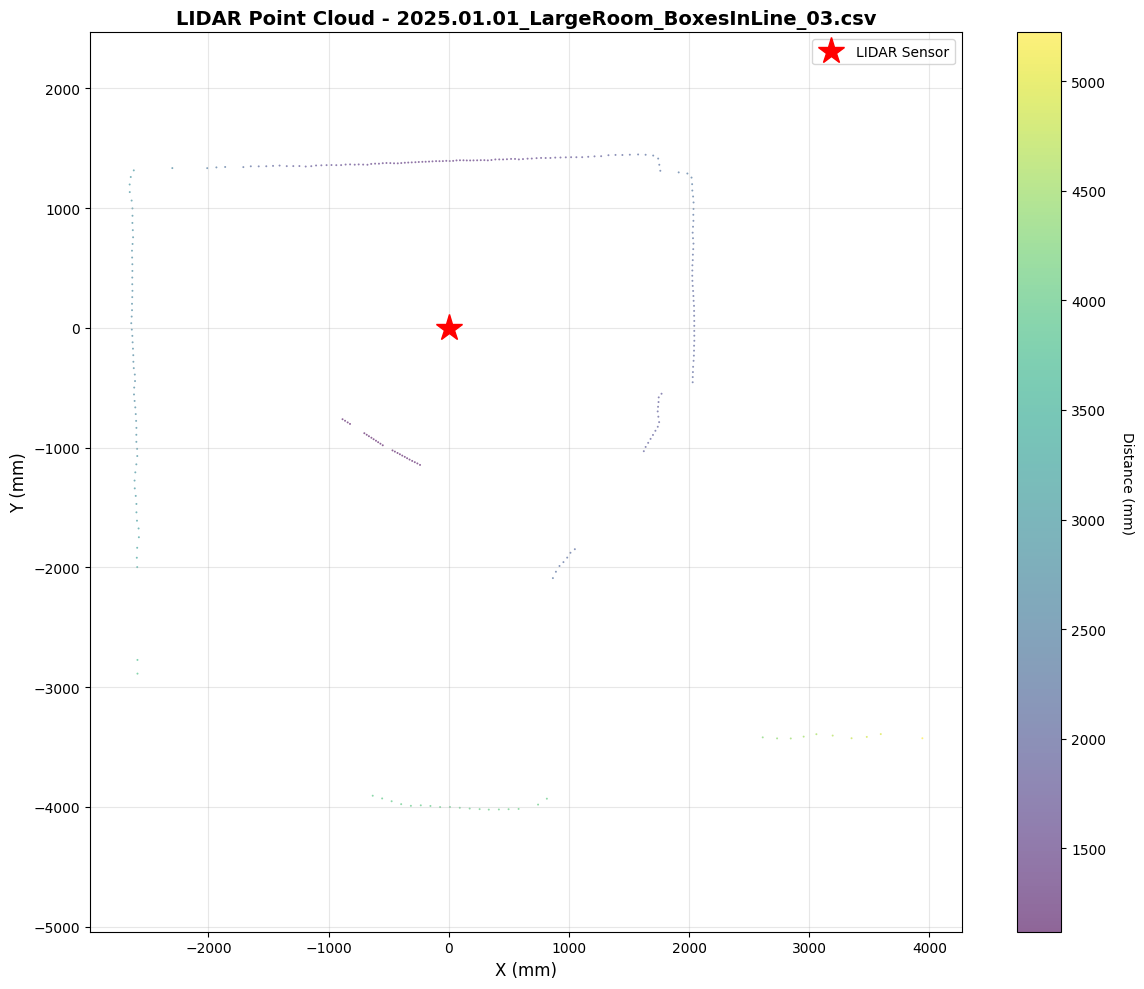


Visualization complete!
Distance range: 1118.75 - 5672.00 mm
Angle range: 0.00 - 359.98 degrees


In [12]:
# Count points per timestamp
counts = df.groupby('timestamp').size()

# Keep only full scans (remove small partial ones)
valid_counts = counts[counts > 200]

# Choose first valid full scan
chosen_ts = valid_counts.index[0]

# Filter dataframe
df_one = df[df['timestamp'] == chosen_ts].copy()

print("Selected timestamp:", chosen_ts)
print("Points in scan:", len(df_one))

# Create a scatter plot of the LiDAR points
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the points with color based on distance for better visualization
scatter = ax.scatter(df_one['x'], df_one['y'], c=df_one['distance_mm'], cmap='viridis', 
                     s=2, alpha=0.6, edgecolors='none')

# Mark the sensor position at origin
ax.plot(0, 0, 'r*', markersize=20, label='LIDAR Sensor', zorder=5)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Distance (mm)', rotation=270, labelpad=20)

# Labels and title
ax.set_xlabel('X (mm)', fontsize=12)
ax.set_ylabel('Y (mm)', fontsize=12)
ax.set_title(f'LIDAR Point Cloud - {csv_file.name}', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nVisualization complete!")
print(f"Distance range: {df['distance_mm'].min():.2f} - {df['distance_mm'].max():.2f} mm")
print(f"Angle range: {df['angle_deg'].min():.2f} - {df['angle_deg'].max():.2f} degrees")

## Section 5: DBSCAN Baseline Clustering


DBSCAN baseline metrics:
 - n_points: 268
 - n_clusters: 6
 - n_noise: 169
 - noise_pct: 63.059701492537314
 - runtime_ms: 2.11499999568332


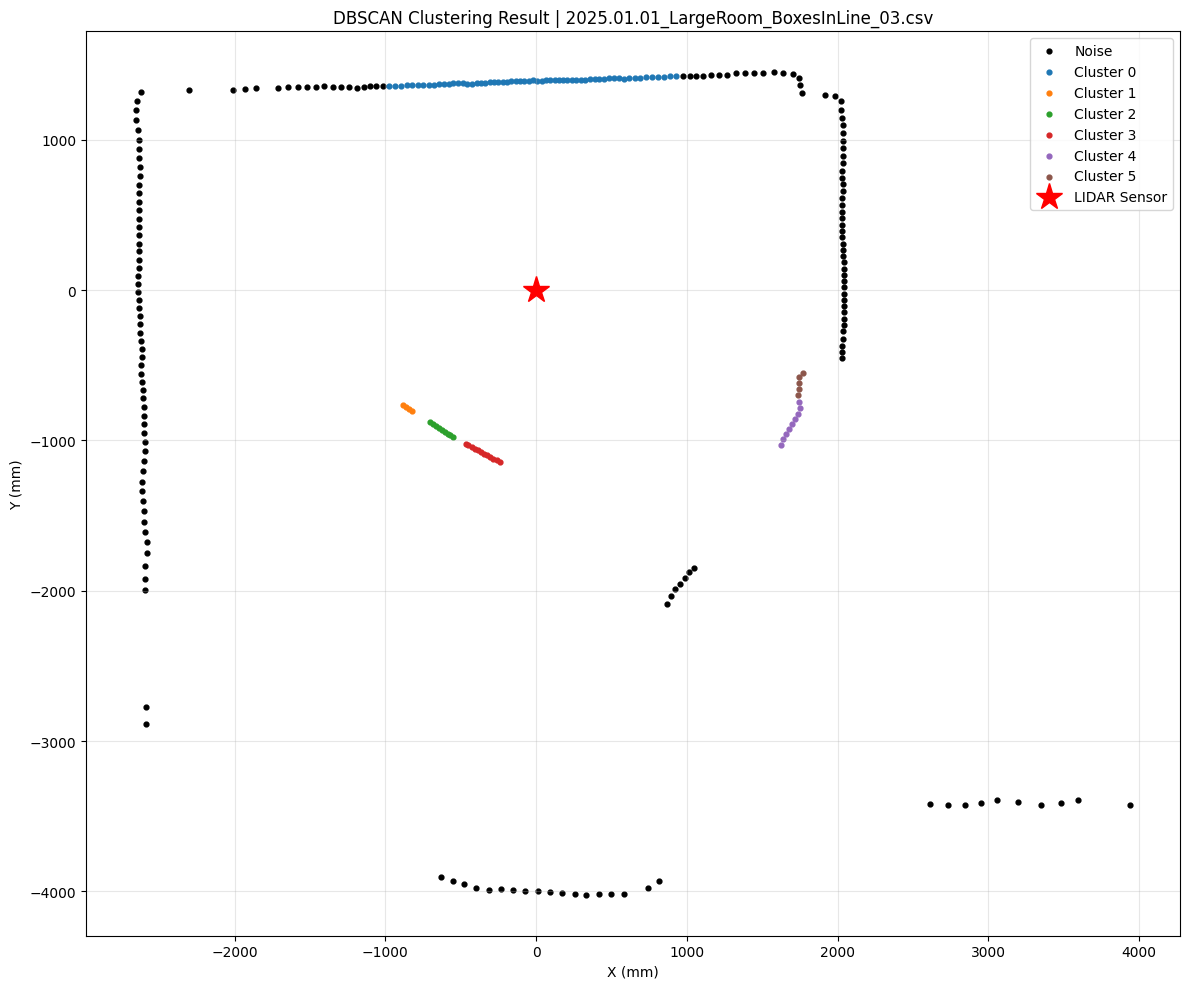

In [26]:
# Baseline DBSCAN parameters (in millimeters)
EPS_MM = 80.0
MIN_SAMPLES = 4

points = df_one[['x', 'y']].to_numpy()
labels, runtime_ms = run_dbscan(points, eps_mm=EPS_MM, min_samples=MIN_SAMPLES)
m = dbscan_metrics(labels)
m['runtime_ms'] = runtime_ms

print('DBSCAN baseline metrics:')
for k, v in m.items():
    print(f" - {k}: {v}")

df_one['cluster'] = labels

unique_labels = np.unique(labels)

fig, ax = plt.subplots(figsize=(12, 10))

for label in unique_labels:
    mask = df_one['cluster'] == label

    if label == -1:
        ax.scatter(
            df_one.loc[mask, 'x'],
            df_one.loc[mask, 'y'],
            c='black',
            s=12,
            label='Noise'
        )
    else:
        ax.scatter(
            df_one.loc[mask, 'x'],
            df_one.loc[mask, 'y'],
            s=12,
            label=f'Cluster {label}'
        )

# Mark sensor position
ax.plot(0, 0, 'r*', markersize=20, label='LIDAR Sensor', zorder=5)

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_title(f"DBSCAN Clustering Result | {csv_file.name}")
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## KERNEL FUNTION

In [13]:
gamma_values = [1e-7, 5e-7, 1e-6]
eps_values = [0.05, 0.1, 0.2]
min_samples_values = [4, 6, 8]

results_kernel = []

for gamma in gamma_values:
    for eps in eps_values:
        for m in min_samples_values:
            for ts in valid_counts.index[:10]:

                df_scan = df[df['timestamp'] == ts].copy()
                df_xy = add_xy_columns(df_scan)
                points = df_xy[['x','y']].to_numpy()

                labels, runtime = run_kernel_dbscan(
                    points,
                    gamma=gamma,
                    eps=eps,
                    min_samples=m
                )

                metrics = dbscan_metrics(labels)

                metrics['runtime_ms'] = runtime
                metrics['timestamp'] = ts
                metrics['gamma'] = gamma
                metrics['eps'] = eps
                metrics['min_samples'] = m

                results_kernel.append(metrics)

results_kernel_df = pd.DataFrame(results_kernel)

summary_kernel = results_kernel_df.groupby(
    ['gamma','eps','min_samples']
).agg({
    'n_clusters': ['mean','std'],
    'noise_pct': ['mean','std'],
    'runtime_ms': ['mean','std']
})

print(summary_kernel)


                              n_clusters            noise_pct            \
                                    mean       std       mean       std   
gamma        eps  min_samples                                             
1.000000e-07 0.05 4                  5.0  0.000000   0.520192  0.261447   
                  6                  5.0  0.000000   0.594543  0.193544   
                  8                  4.1  0.316228   2.970803  0.805515   
             0.10 4                  4.6  0.516398   0.074214  0.156459   
                  6                  4.6  0.516398   0.074214  0.156459   
                  8                  4.0  0.000000   1.632746  1.333715   
             0.20 4                  2.8  0.421637   0.000000  0.000000   
                  6                  2.9  0.316228   0.000000  0.000000   
                  8                  3.0  0.000000   0.000000  0.000000   
5.000000e-07 0.05 4                  5.9  0.316228   0.891395  0.260053   
                  6      

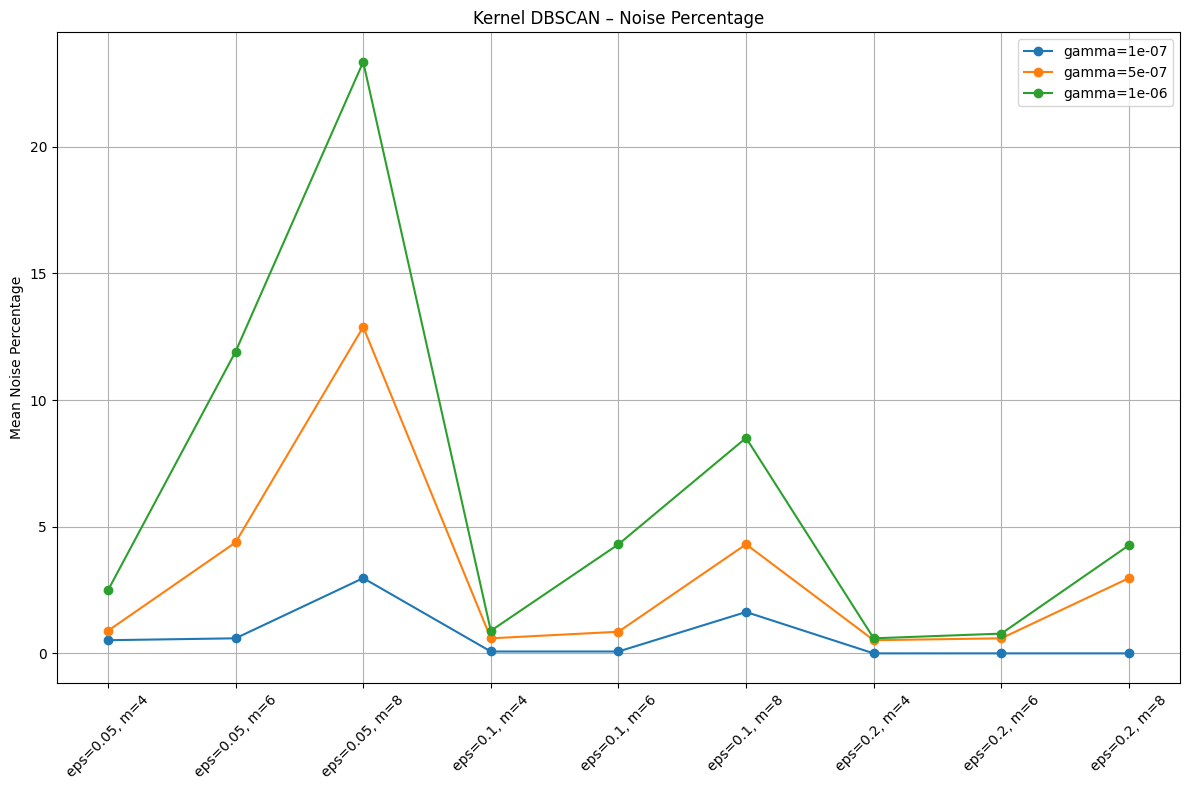

In [14]:
import matplotlib.pyplot as plt

# Extract mean noise only
noise_mean = results_kernel_df.groupby(
    ['gamma','eps','min_samples']
)['noise_pct'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 8))

for gamma in noise_mean['gamma'].unique():
    subset = noise_mean[noise_mean['gamma'] == gamma]
    ax.plot(
        range(len(subset)),
        subset['noise_pct'],
        marker='o',
        label=f'gamma={gamma}'
    )

ax.set_xticks(range(len(subset)))
ax.set_xticklabels(
    [f"eps={e}, m={m}" for e, m in zip(subset['eps'], subset['min_samples'])],
    rotation=45
)

ax.set_ylabel("Mean Noise Percentage")
ax.set_title("Kernel DBSCAN – Noise Percentage")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


Using timestamp: 1767277060.117305
Points in scan: 268
Runtime (ms): 3.117899992503226


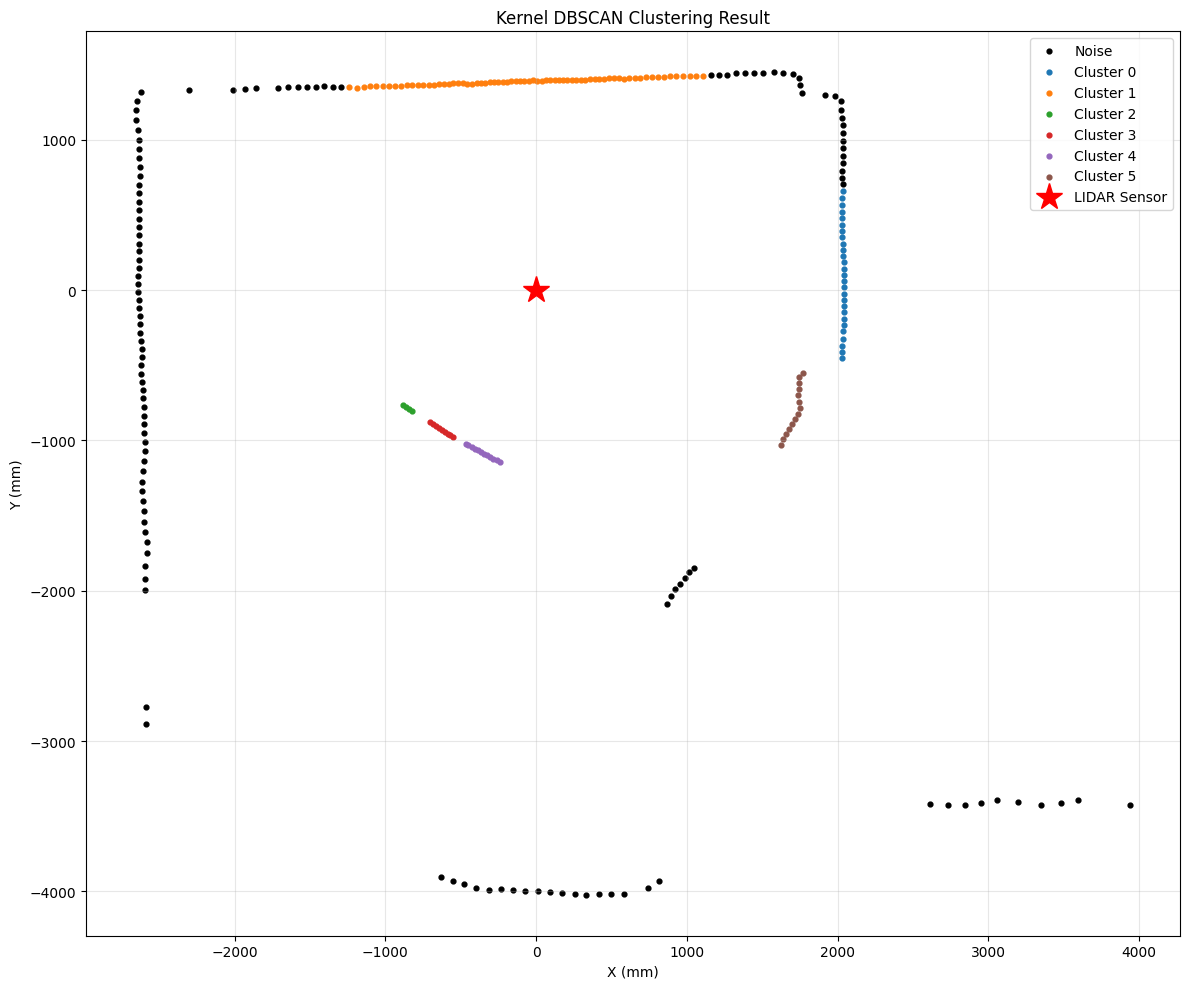


Kernel DBSCAN Metrics:
n_points: 268
n_clusters: 6
n_noise: 132
noise_pct: 49.25373134328358


In [32]:

# Select ONE full scan
ts = valid_counts.index[0]  # choose one timestamp
print("Using timestamp:", ts)

df_one = df[df['timestamp'] == ts].copy()

# Add XY coordinates
angles_rad = np.radians(df_one['angle_deg'].to_numpy())
r = df_one['distance_mm'].to_numpy()
df_one['x'] = r * np.cos(angles_rad)
df_one['y'] = r * np.sin(angles_rad)

points = df_one[['x','y']].to_numpy()

print("Points in scan:", len(points))


#  Kernel DBSCAN function
def run_kernel_dbscan(points_xy,
                      gamma=1.000000e-05,
                      eps=0.02,
                      min_samples=4):

    t0 = time.perf_counter()

    K = rbf_kernel(points_xy, gamma=gamma)
    D = 1.0 - K

    labels = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric='precomputed'
    ).fit_predict(D)

    runtime_ms = (time.perf_counter() - t0) * 1000.0

    return labels, runtime_ms


# Run clustering
labels, runtime = run_kernel_dbscan(
    points,
    gamma=1.000000e-06,
    eps=0.008,
    min_samples=4
)

print("Runtime (ms):", runtime)

# Assign labels (lengths now match)
df_one['cluster'] = labels


# Plot clusters (noise in black)
unique_labels = np.unique(labels)

fig, ax = plt.subplots(figsize=(12, 10))

for label in unique_labels:
    mask = df_one['cluster'] == label

    if label == -1:
        ax.scatter(
            df_one.loc[mask, 'x'],
            df_one.loc[mask, 'y'],
            c='black',
            s=12,
            label='Noise'
        )
    else:
        ax.scatter(
            df_one.loc[mask, 'x'],
            df_one.loc[mask, 'y'],
            s=12,
            label=f'Cluster {label}'
        )

# Mark sensor position
ax.plot(0, 0, 'r*', markersize=20, label='LIDAR Sensor', zorder=5)

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_title('Kernel DBSCAN Clustering Result')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# Print simple metrics
n_points = len(labels)
n_noise = np.sum(labels == -1)
n_clusters = len(np.unique(labels[labels >= 0]))

print("\nKernel DBSCAN Metrics:")
print("n_points:", n_points)
print("n_clusters:", n_clusters)
print("n_noise:", n_noise)
print("noise_pct:", 100 * n_noise / n_points)


## Section 6: Distance-Binned Analysis 

This shows how LIDAR performance degrades with distance. Analysis by range bins helps identify:
- Noise percentage across different distances
- Number of objects detectable at each range
- Optimal measurement zones for your application


Distance-binned DBSCAN performance:


,n_points,n_clusters,n_noise,noise_pct,range_bin
0,62,2,4,6.451613,"(1000.0, 1500.0]"
1,55,2,15,27.272727,"(1500.0, 2000.0]"
2,64,0,64,100.000000,"(2000.0, 2500.0]"
3,86,0,86,100.000000,"(2500.0, 5000.0]"


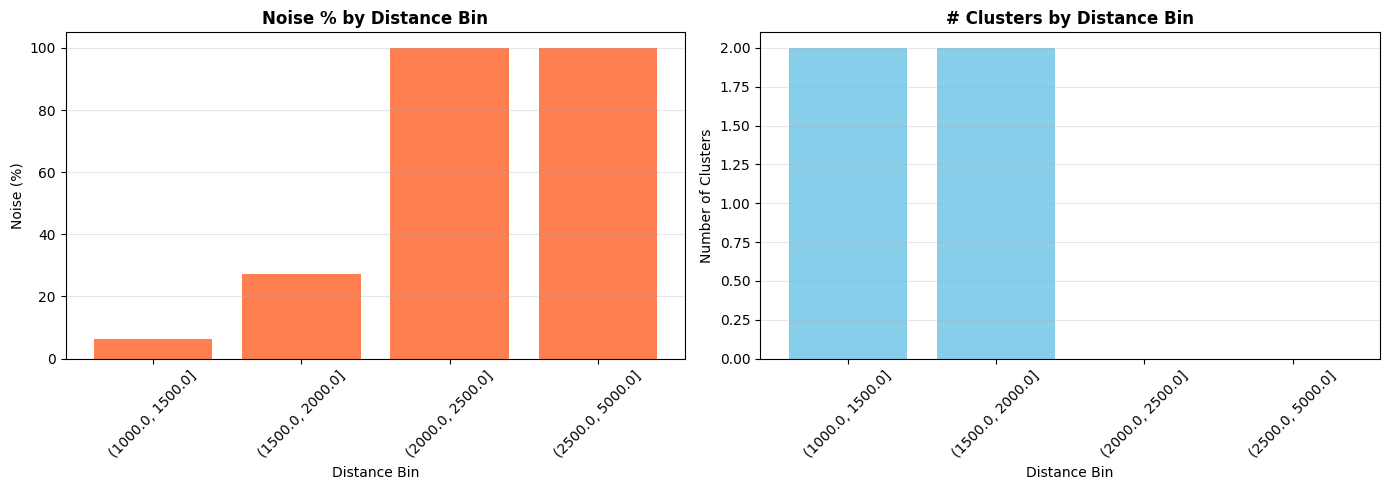

In [18]:
# Define range bins (mm)
bin_edges_mm = np.array([0, 500, 1000, 1500, 2000, 2500, 5000])
dfb = add_distance_bin(df_one, bin_edges_mm)

# For each bin: number of points, noise %, number of clusters
rows = []
for b, g in dfb.groupby('range_bin', observed=True):
    if len(g) == 0:
        continue
    labels_b = g['cluster'].to_numpy()
    mb = dbscan_metrics(labels_b)
    mb['range_bin'] = str(b)
    rows.append(mb)

summary = pd.DataFrame(rows)
print("\nDistance-binned DBSCAN performance:")
display(summary)

# Visualize degradation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(range(len(summary)), summary['noise_pct'].values, color='coral')
ax[0].set_title('Noise % by Distance Bin', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Noise (%)')
ax[0].set_xlabel('Distance Bin')
ax[0].set_xticks(range(len(summary)))
ax[0].set_xticklabels(summary['range_bin'].values, rotation=45)
ax[0].grid(True, alpha=0.3, axis='y')

ax[1].bar(range(len(summary)), summary['n_clusters'].values, color='skyblue')
ax[1].set_title('# Clusters by Distance Bin', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Number of Clusters')
ax[1].set_xlabel('Distance Bin')
ax[1].set_xticks(range(len(summary)))
ax[1].set_xticklabels(summary['range_bin'].values, rotation=45)
ax[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Section 7: Baseline Comparison Across All CSV Files

In [19]:
# Analyze single file (the one currently loaded)
print(f"\nAnalyzing: {csv_file.name}")
print("=" * 60)

try:
    # Use the dataframe already loaded in 'df'
    points = df_one[['x', 'y']].to_numpy()
    labels, rt_ms = run_dbscan(points, eps_mm=EPS_MM, min_samples=MIN_SAMPLES)
    m = dbscan_metrics(labels)
    m['runtime_ms'] = rt_ms
    m['file'] = csv_file.name
    
    result_table = pd.DataFrame([m])[['file', 'n_points', 'n_clusters', 'n_noise', 'noise_pct', 'runtime_ms']]
    print("\nDetailed Analysis:")
    display(result_table)
    
    print(f"\n✓ Successfully processed {csv_file.name}")
except Exception as e:
    print(f"✗ Error analyzing {csv_file.name}: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 60)
print("To analyze a different file, modify the cell below:")



Analyzing: 2025.01.01_LargeRoom_BoxesInLine_03.csv

Detailed Analysis:


,file,n_points,n_clusters,n_noise,noise_pct,runtime_ms
0,2025.01.01_LargeRoom_BoxesInLine_03.csv,268,3,170,63.432836,1.3189



✓ Successfully processed 2025.01.01_LargeRoom_BoxesInLine_03.csv

To analyze a different file, modify the cell below:


##  Polar Plot Visualization

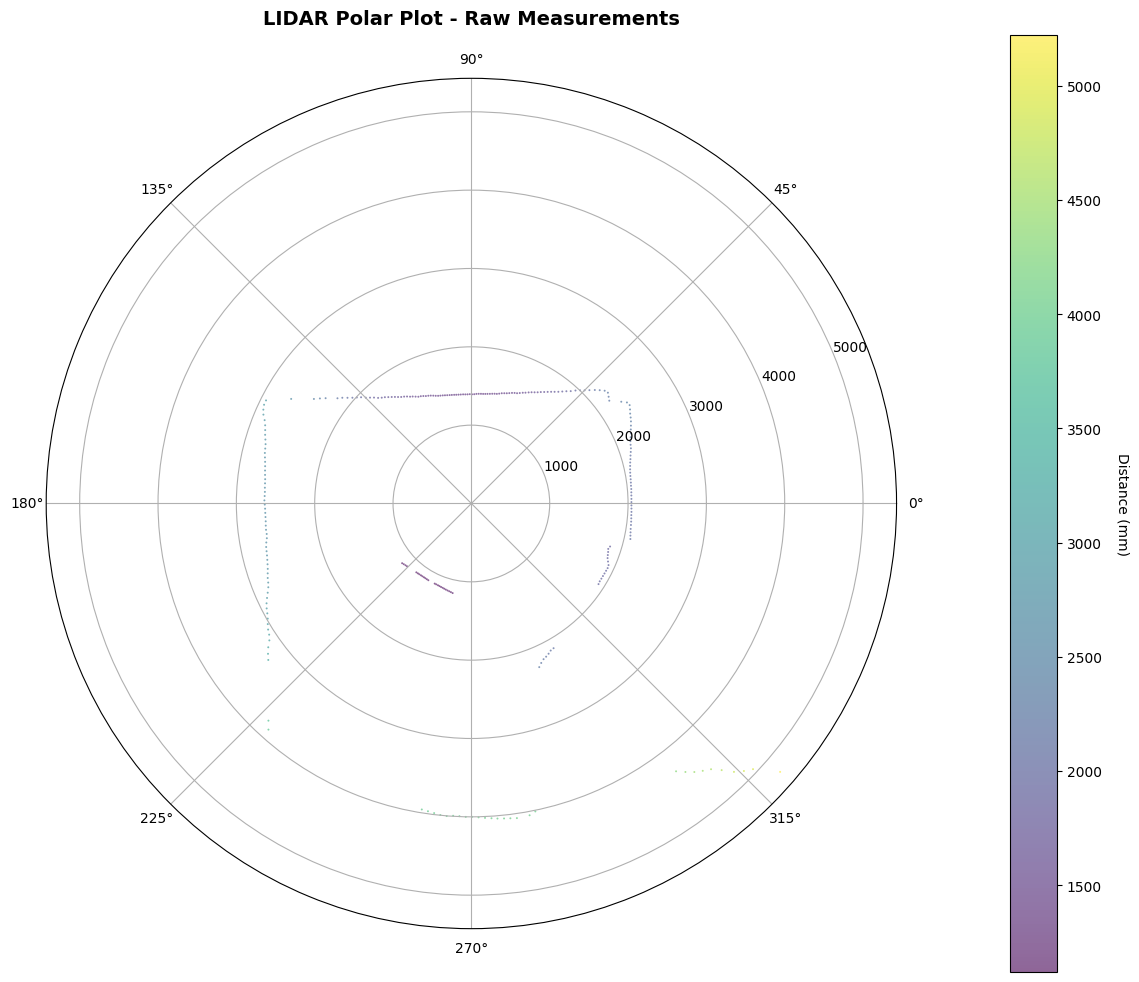

In [20]:
# Create a polar plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

# Convert angles to radians for polar plot
theta = np.radians(df_one['angle_deg'].values)
r = df_one['distance_mm'].values

# Plot in polar coordinates
scatter = ax.scatter(theta, r, c=r, cmap='viridis', s=2, alpha=0.6, edgecolors='none')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Distance (mm)', rotation=270, labelpad=20)

# Title
ax.set_title('LIDAR Polar Plot - Raw Measurements', fontsize=14, fontweight='bold', pad=20)
ax.set_theta_zero_location('E')  # Set 0 degrees to the east (right)
ax.set_theta_direction(1)  # Counterclockwise

plt.tight_layout()
plt.show()